# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [13]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [14]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results"

DATASET_NAME = "data_00_20_w724_s10"
dataset_dir = results_root / DATASET_NAME
analysis_dir = dataset_dir / "reconstruction_analysis"

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (5): ['AE_12dim_0004', 'AE_20dim_0006', 'AE_3dim_0005', 'linearAE_12dim_0011', 'linearAE_3dim_0004']


In [15]:
def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    record = {"model": model_dir.name}

    errors_path = model_dir / "reconstruction_errors.json"
    if errors_path.exists():
        record.update(flatten_metric_stats(load_json(errors_path), prefix="err_"))
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    mst_path = model_dir / "mst_comparison_metrics.json"
    if mst_path.exists():
        record.update(flatten_metric_stats(load_json(mst_path), prefix="mst_"))
    else:
        print(f"Missing mst_comparison_metrics.json for {model_dir.name}")

    return record


records = [load_model_stats(p) for p in model_dirs]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df

Missing mst_comparison_metrics.json for AE_20dim_0006


,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_max,mst_avg_path_len_unweighted_recon_count,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AE_12dim_0004,0.000362,0.000162,0.000132,0.000336,0.000968,0.013939,0.003251,0.008762,0.013424,0.023828,6.743870,1.434640,4.166496,6.634828,11.263485,41.0,78.569016,5.396957,66.481994,75.900277,78.947368,81.440443,90.304709,41.0,65.018347,...,14.683491,41.0,10.781178,1.382604,9.011172,9.665004,10.329701,11.776465,13.209623,41.0,0.871690,0.660961,0.023354,0.187509,0.695643,1.366661,2.071823,41.0,63.902439,18.557754,20.0,50.0,70.0,80.0,100.0
AE_20dim_0006,0.000400,0.000179,0.000176,0.000389,0.001063,0.014728,0.003460,0.009786,0.013956,0.025078,7.083890,1.527626,4.799416,7.137837,11.803842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE_3dim_0005,0.000474,0.000216,0.000152,0.000488,0.001040,0.015752,0.004136,0.008841,0.014963,0.024784,7.668563,1.826769,4.461875,7.998229,11.673943,41.0,74.535504,6.267796,62.049861,70.083102,73.684211,80.332410,85.595568,41.0,59.797708,...,14.683491,41.0,10.624525,1.428916,8.479867,9.641542,10.388485,11.290231,13.918122,41.0,0.863095,0.708828,0.025114,0.302689,0.698137,1.390322,3.059901,41.0,60.487805,17.022224,20.0,50.0,60.0,70.0,100.0
linearAE_12dim_0011,0.002766,0.001499,0.001390,0.002479,0.008231,0.039187,0.009822,0.028170,0.037705,0.071822,18.530298,4.431652,13.496486,18.023565,32.842609,41.0,47.652186,6.271803,34.349030,42.936288,47.645429,52.631579,58.725762,41.0,31.494837,...,14.683491,41.0,9.825773,1.046058,8.370258,9.082995,9.653296,10.296827,13.004959,41.0,1.983287,1.521821,0.043847,0.903200,1.503574,2.816501,5.535315,41.0,35.121951,13.061767,10.0,30.0,30.0,40.0,60.0
linearAE_3dim_0004,0.008334,0.002241,0.004547,0.008089,0.013534,0.071059,0.009407,0.053062,0.069856,0.089800,32.757328,4.424218,24.410721,32.558182,42.114071,41.0,31.714073,5.495709,21.606648,27.700831,31.578947,35.457064,46.537396,41.0,18.970699,...,14.683491,41.0,11.711044,0.768894,10.606036,10.914311,11.768415,12.403774,12.892426,41.0,1.886985,0.984440,0.338945,1.109916,1.791876,2.508961,3.885110,41.0,27.560976,12.405742,10.0,20.0,30.0,40.0,60.0


In [16]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

print("Reconstruction error means (lower is better):")
display(err_means.sort_values(available_err_metrics[0]))

print("Reconstruction error std:")
display(err_stds)

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)
err_ranks = err_ranks.sort_values("avg_rank")

print("Reconstruction error rank (lower is better):")
display(err_ranks)

Reconstruction error means (lower is better):


,MSE,MAE,Frobenius
model,,,
AE_12dim_0004,0.000362,0.013939,6.743870
AE_20dim_0006,0.000400,0.014728,7.083890
AE_3dim_0005,0.000474,0.015752,7.668563
linearAE_12dim_0011,0.002766,0.039187,18.530298
linearAE_3dim_0004,0.008334,0.071059,32.757328


Reconstruction error std:


,MSE,MAE,Frobenius
model,,,
AE_12dim_0004,0.000162,0.003251,1.434640
AE_20dim_0006,0.000179,0.003460,1.527626
AE_3dim_0005,0.000216,0.004136,1.826769
linearAE_12dim_0011,0.001499,0.009822,4.431652
linearAE_3dim_0004,0.002241,0.009407,4.424218


Reconstruction error rank (lower is better):


,MSE,MAE,Frobenius,avg_rank
model,,,,
AE_12dim_0004,1.0,1.0,1.0,1.0
AE_20dim_0006,2.0,2.0,2.0,2.0
AE_3dim_0005,3.0,3.0,3.0,3.0
linearAE_12dim_0011,4.0,4.0,4.0,4.0
linearAE_3dim_0004,5.0,5.0,5.0,5.0


In [17]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)

print("MST comparison means:")
display(mst_means)

higher_better = {"edge_overlap_pct", "edge_jaccard_pct", "betweenness_topk_overlap_pct"}
lower_better = {"degree_l1", "avg_path_len_diff", "avg_path_len_unweighted_diff"}


def rank_mst(df: pd.DataFrame):
    ranks = pd.DataFrame(index=df.index)
    for metric in df.columns:
        if metric in higher_better:
            ranks[metric] = df[metric].rank(ascending=False)
        else:
            ranks[metric] = df[metric].rank(ascending=True)
    ranks["avg_rank"] = ranks.mean(axis=1)
    return ranks.sort_values("avg_rank")


mst_ranks = rank_mst(mst_means)
print("MST rank (higher overlap is better, lower diffs are better):")
display(mst_ranks)

MST comparison means:


,edge_overlap_pct,edge_jaccard_pct,degree_l1,avg_path_len_diff,avg_path_len_unweighted_diff,betweenness_topk_overlap_pct
model,,,,,,
AE_12dim_0004,78.569016,65.018347,0.089880,0.586369,0.871690,63.902439
AE_20dim_0006,NaN,NaN,NaN,NaN,NaN,NaN
AE_3dim_0005,74.535504,59.797708,0.089880,0.550084,0.863095,60.487805
linearAE_12dim_0011,47.652186,31.494837,0.129363,1.351237,1.983287,35.121951
linearAE_3dim_0004,31.714073,18.970699,0.141760,1.670977,1.886985,27.560976


MST rank (higher overlap is better, lower diffs are better):


,edge_overlap_pct,edge_jaccard_pct,degree_l1,avg_path_len_diff,avg_path_len_unweighted_diff,betweenness_topk_overlap_pct,avg_rank
model,,,,,,,
AE_12dim_0004,1.0,1.0,2.0,2.0,2.0,1.0,1.500000
AE_3dim_0005,2.0,2.0,1.0,1.0,1.0,2.0,1.500000
linearAE_12dim_0011,3.0,3.0,3.0,3.0,4.0,3.0,3.166667
linearAE_3dim_0004,4.0,4.0,4.0,4.0,3.0,4.0,3.833333
AE_20dim_0006,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
summary = pd.DataFrame(index=stats_df.index)
summary["err_score"] = err_ranks["avg_rank"]
summary["mst_score"] = mst_ranks["avg_rank"]
summary["combined_score"] = summary.mean(axis=1)
summary = summary.sort_values("combined_score")

print("Combined score (lower is better):")
display(summary)

Combined score (lower is better):


,err_score,mst_score,combined_score
model,,,
AE_12dim_0004,1.0,1.500000,1.250000
AE_20dim_0006,2.0,NaN,2.000000
AE_3dim_0005,3.0,1.500000,2.250000
linearAE_12dim_0011,4.0,3.166667,3.583333
linearAE_3dim_0004,5.0,3.833333,4.416667


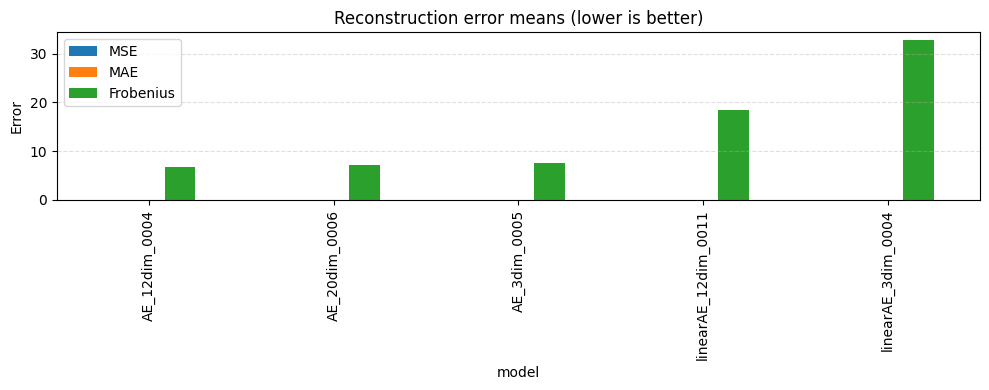

In [19]:
ax = err_means.plot(
    kind="bar",
    figsize=(10, 4),
    title="Reconstruction error means (lower is better)",
)
ax.set_ylabel("Error")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# K-based comparison plots
Build plots for error metrics across K and methods.

In [20]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

method_order = ["PCA", "linearAE", "AE"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {"PCA": "PCA", "linearAE": "LinearAE", "AE": "AE"}
method_colors = {"PCA": "tab:blue", "linearAE": "tab:green", "AE": "tab:red"}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['linearAE', 'AE']
K values: [np.int64(3), np.int64(12), np.int64(20)]


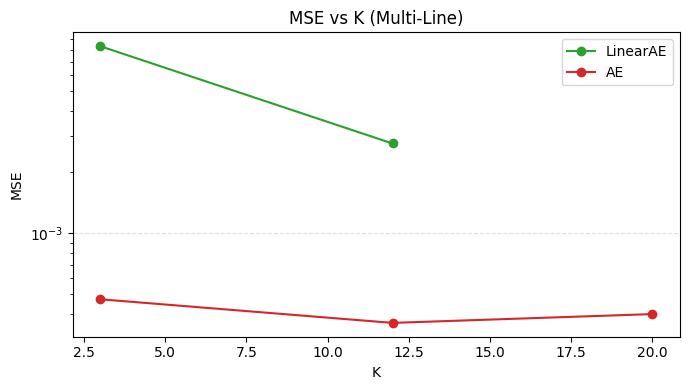

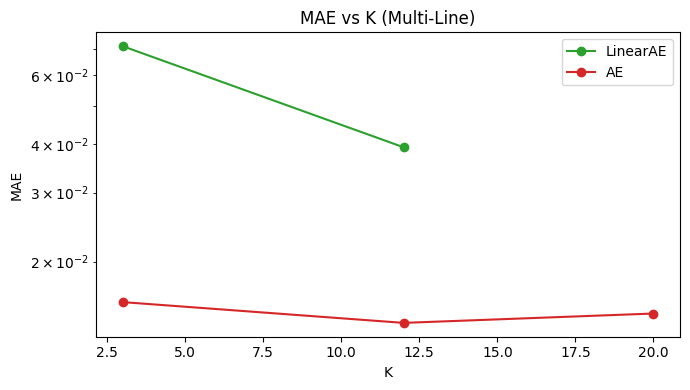

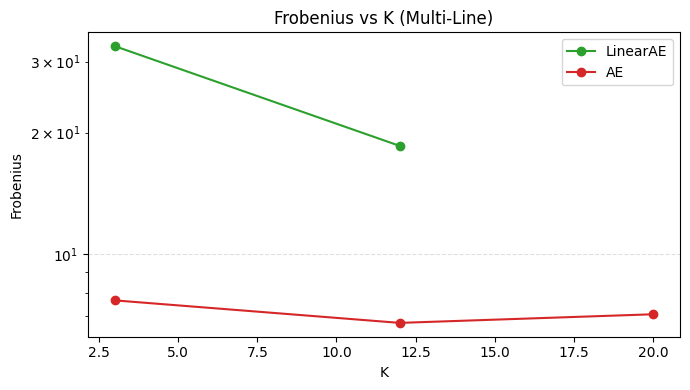

In [21]:
for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        ax.plot(
            subset["K"],
            subset["error"],
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

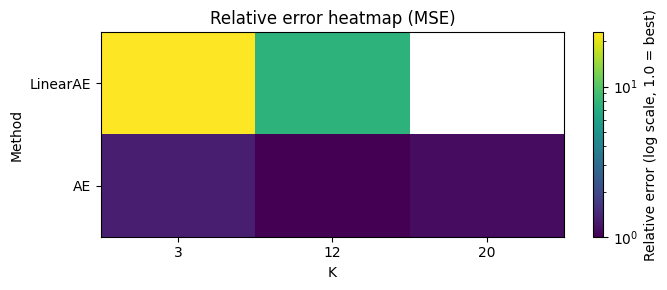

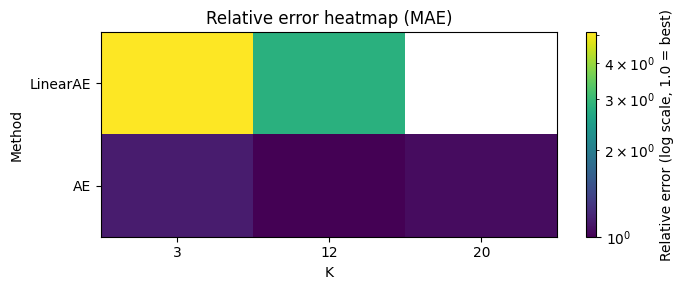

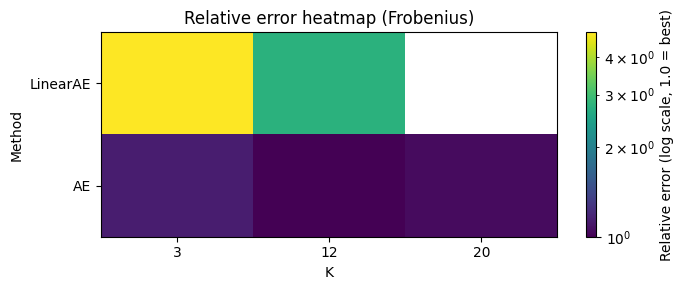

In [22]:
for metric in available_err_metrics:
    pivot = (
        err_long[err_long["metric"] == metric]
        .pivot(index="method", columns="K", values="error")
        .reindex(index=methods, columns=ks_sorted)
    )

    rel = pivot / np.nanmin(pivot.to_numpy())
    rel_values = rel.to_numpy()
    rel_min = np.nanmin(rel_values)
    rel_max = np.nanmax(rel_values)
    rel_min = max(rel_min, 1e-12)
    data = np.ma.masked_invalid(rel_values)

    fig, ax = plt.subplots(figsize=(7, 3))
    im = ax.imshow(
        data,
        cmap="viridis",
        aspect="auto",
        norm=LogNorm(vmin=rel_min, vmax=rel_max),
    )

    ax.set_title(f"Relative error heatmap ({metric})")
    ax.set_xlabel("K")
    ax.set_ylabel("Method")
    ax.set_xticks(range(len(ks_sorted)))
    ax.set_xticklabels(ks_sorted)
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels([method_labels.get(m, m) for m in methods])

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Relative error (log scale, 1.0 = best)")

    plt.tight_layout()
    plt.show()

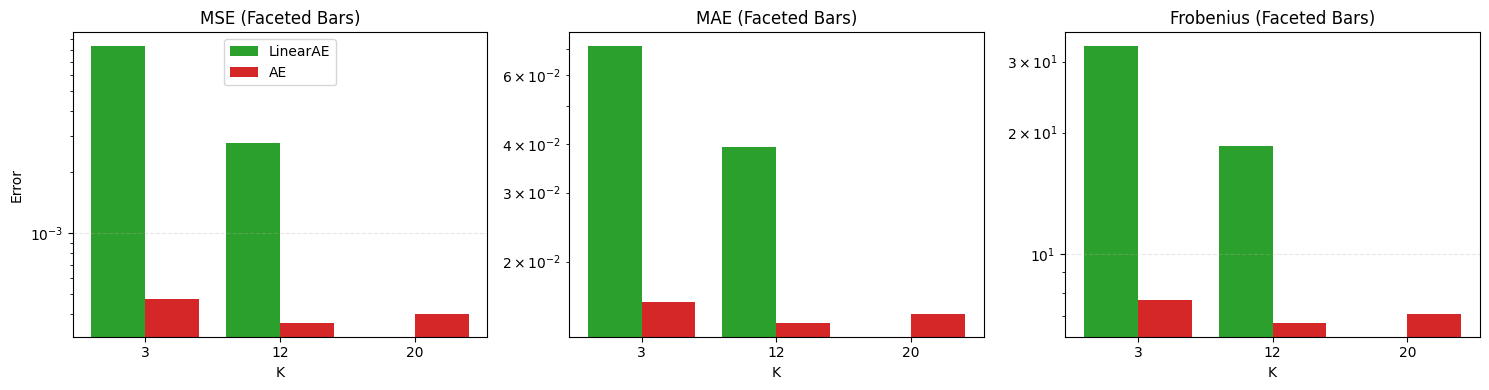

In [23]:
fig, axes = plt.subplots(1, len(available_err_metrics), figsize=(5 * len(available_err_metrics), 4))
if len(available_err_metrics) == 1:
    axes = [axes]

x = np.arange(len(ks_sorted))
width = 0.8 / max(len(methods), 1)

for ax, metric in zip(axes, available_err_metrics):
    pivot = (
        err_long[err_long["metric"] == metric]
        .pivot(index="K", columns="method", values="error")
        .reindex(index=ks_sorted, columns=methods)
    )

    for i, method in enumerate(methods):
        values = pivot[method]
        offset = (i - (len(methods) - 1) / 2) * width
        ax.bar(
            x + offset,
            values,
            width=width,
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} (Faceted Bars)")
    ax.set_xlabel("K")
    ax.set_xticks(x)
    ax.set_xticklabels(ks_sorted)
    ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Error")
axes[0].legend()
plt.tight_layout()
plt.show()

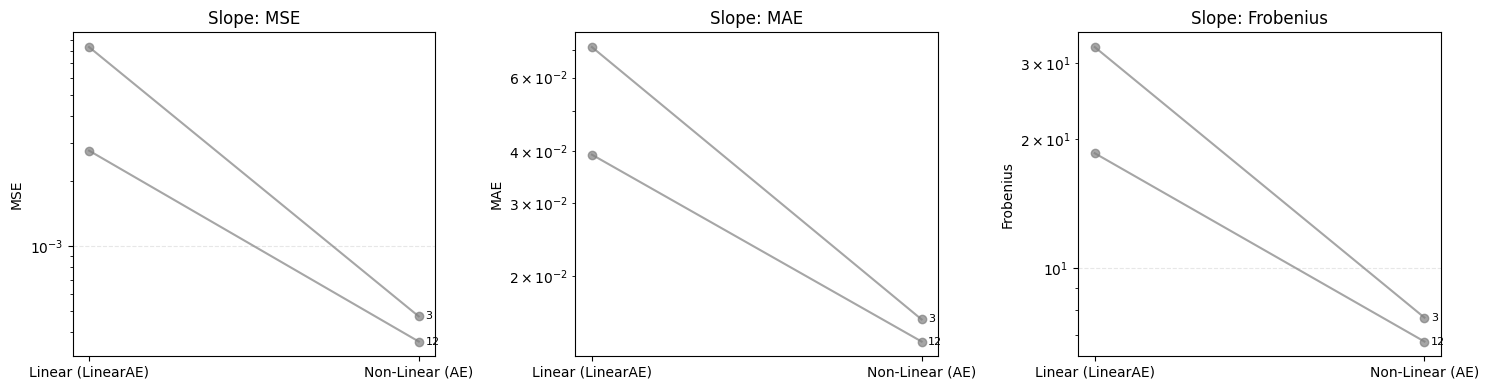

In [24]:
linear_candidates = ["PCA", "linearAE"]
linear_method = next((m for m in linear_candidates if m in methods), None)
nonlinear_method = "AE" if "AE" in methods else None

if linear_method is None or nonlinear_method is None:
    print("Slope chart skipped: need both a linear method (PCA or linearAE) and AE.")
else:
    fig, axes = plt.subplots(1, len(available_err_metrics), figsize=(5 * len(available_err_metrics), 4))
    if len(available_err_metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, available_err_metrics):
        pivot = (
            err_long[err_long["metric"] == metric]
            .pivot(index="K", columns="method", values="error")
            .reindex(index=ks_sorted)
        )

        for k in ks_sorted:
            if (
                k in pivot.index
                and linear_method in pivot.columns
                and nonlinear_method in pivot.columns
            ):
                y1 = pivot.loc[k, linear_method]
                y2 = pivot.loc[k, nonlinear_method]
                if pd.notna(y1) and pd.notna(y2):
                    ax.plot([0, 1], [y1, y2], marker="o", color="gray", alpha=0.7)
                    if len(ks_sorted) <= 10:
                        ax.text(1.02, y2, str(k), va="center", fontsize=8)

        ax.set_title(f"Slope: {metric}")
        ax.set_xticks([0, 1])
        ax.set_xticklabels([
            f"Linear ({method_labels.get(linear_method, linear_method)})",
            "Non-Linear (AE)",
        ])
        ax.set_ylabel(metric)
        ax.set_yscale("log")
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()